## Imports

In [3]:
from transformer_lens import HookedTransformer, patching, utils
from importlib import reload
import torch, gc
import torch.nn as nn
from tqdm import tqdm

In [1]:
!hostname

thin


In [264]:
gc.collect()
torch.cuda.empty_cache()

## Model Loading

In [7]:
# Load a model (eg GPT-2 Small)
model = HookedTransformer.from_pretrained("gpt2-xl")
# model = HookedTransformer.from_pretrained("gpt-j")

model.eval()
dim = model.QK.shape[-1]
print(model)

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded pretrained model gpt2-xl into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-47): 48 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out):

## Atomic Tests

In [3]:
prompt, tok = "When Bob and France went to the store, Bob asked"            , 3
prompt, tok = "When Mary and Bob went to the store, Bob asked"              , 3
prompt, tok = "the French Iron King, aka '"                                 , 4
prompt, tok = "The Empire State Building is a great monument"               , 4
prompt, tok = "the molecule HU765DGB introduced herself: 'hi, my name is"   , 7
prompt, tok = "Man of steel, commonly known as"                             , 3
prompt, tok = "Alan Bean was an American astronaut, born on March 15, 1932 in Wheeler, Texas. He received a Bachelor of Science degree at the University of \
Texas at Austin in 1955 and was chosen by NASA in 1963. Alan Bean was a"   , 44
prompt, tok = "The Eiffel Tower "                                           , 5
prompt, tok = "Alan Bean was an ", 2
prompt, tok = "Barack Obama was an ", 3

toks = model.to_str_tokens(prompt)
for i,t  in enumerate(toks): print(i, "\t", t, "  <--" if i==tok else "")

0 	 <|endoftext|> 
1 	 Bar 
2 	 ack 
3 	  Obama   <--
4 	  was 
5 	  an 
6 	   


### Test Generation

In [4]:

res = model.generate(prompt, max_new_tokens=10, temperature=0, return_type="str")
print(res)
# model.to_str_tokens(res)


  0%|          | 0/10 [00:00<?, ?it/s]

Barack Obama was an ersatz president. He was a man who had


### Choose layer and extract representation

In [35]:

layer = 15
hook_name = utils.get_act_name('resid_post', layer=layer)
print(hook_name)

#get whole Buffer : heavy !
logits, activations = model.run_with_cache(prompt)
for name, param in model.named_parameters():
    if name.startswith("blocks.0."):
        print(name, param.shape)
print(logits.shape)
print(activations[hook_name].shape)
representation = activations[hook_name][0,tok,:].unsqueeze(0)
print(representation.shape)


blocks.15.hook_resid_post
blocks.0.attn.W_Q torch.Size([25, 1600, 64])
blocks.0.attn.W_O torch.Size([25, 64, 1600])
blocks.0.attn.b_Q torch.Size([25, 64])
blocks.0.attn.b_O torch.Size([1600])
blocks.0.attn.W_K torch.Size([25, 1600, 64])
blocks.0.attn.W_V torch.Size([25, 1600, 64])
blocks.0.attn.b_K torch.Size([25, 64])
blocks.0.attn.b_V torch.Size([25, 64])
blocks.0.mlp.W_in torch.Size([1600, 6400])
blocks.0.mlp.b_in torch.Size([6400])
blocks.0.mlp.W_out torch.Size([6400, 1600])
blocks.0.mlp.b_out torch.Size([1600])
torch.Size([1, 7, 50257])
torch.Size([1, 7, 1600])
torch.Size([1, 1600])


In [56]:
 #2nd option, don't store the whole cache but use a hook to store the relevant activation.

def get_representation(model: HookedTransformer, tokens, token_inds, layer:int, verbose:bool=False ):
    """extract model representation of token [token_inds] at layer [layer]
    Args:
        model: HookedTransformer form TransformerLens
        tokens: (batch, N) tokenized texts to process
        token_inds: (batch) index of tokens where to extract representation
        layer: layer at which to retreive the representations
    """ 

    dim = model.QK.shape[-1]
    b_size = tokens.shape[0]
    assert len(token_inds) == b_size
    buffer = torch.zeros(b_size, dim)       #create buffer where to store representations
    hook_name = utils.get_act_name('resid_post', layer=layer)   # get hook name for the layer output 
    if verbose: print(f"extract representation of tokens {token_inds} at hook {hook_name}")
    
    def save_activation(tensor, buffer, inds):
        """Save wanted activation in buffer
        Args:
            tensor: the act cache to modify
            inds, ()the token index that we want to overwrite 
        """
        # print(hook.name)
        # print("got tensor of shape", tensor.shape)
        # print(tensor[:,inds,:].shape)
        buffer[:] = torch.vstack([tensor[i,inds[i],:] for i in range(len(inds))])
        return tensor
    
    with torch.no_grad():
        model.run_with_hooks(
            tokens,
            return_type=None,
            fwd_hooks=[(hook_name, lambda tensor, hook: save_activation(tensor, buffer, token_inds) )],
        )
    return buffer
tokens = model.to_tokens([prompt,prompt])
print(tokens)
rep = get_representation(model, tokens=tokens, token_inds=[tok,tok], layer=layer, verbose=True)
print(rep)
rep[0].view(1,-1).allclose(representation.cpu())

tensor([[50256, 10374,   441,  2486,   373,   281,   220],
        [50256, 10374,   441,  2486,   373,   281,   220]], device='cuda:0')
extract representation of tokens [3, 3] at hook blocks.20.hook_resid_post
tensor([[-2.0139, -0.9221, -0.7283,  ..., -4.5380, -0.6124, -1.6715],
        [-2.0139, -0.9221, -0.7283,  ..., -4.5380, -0.6124, -1.6715]])


False

In [57]:
type(rep)

torch.Tensor

### Check hooks call order 

In [6]:
print("Num tokens:", len(model.to_tokens(prompt)[0]))

def print_name_shape_hook_function(activation, hook):
    print(hook.name, activation.shape)

not_in_late_block_filter = lambda name: name.startswith("blocks.11") or not name.startswith("blocks")

model.run_with_hooks(
    prompt,
    return_type=None,
    fwd_hooks=[(not_in_late_block_filter, print_name_shape_hook_function)],
)

Num tokens: 7
hook_embed torch.Size([1, 7, 1600])
hook_pos_embed torch.Size([1, 7, 1600])
blocks.11.hook_resid_pre torch.Size([1, 7, 1600])
blocks.11.ln1.hook_scale torch.Size([1, 7, 1])
blocks.11.ln1.hook_normalized torch.Size([1, 7, 1600])
blocks.11.ln1.hook_scale torch.Size([1, 7, 1])
blocks.11.ln1.hook_normalized torch.Size([1, 7, 1600])
blocks.11.ln1.hook_scale torch.Size([1, 7, 1])
blocks.11.ln1.hook_normalized torch.Size([1, 7, 1600])
blocks.11.attn.hook_q torch.Size([1, 7, 25, 64])
blocks.11.attn.hook_k torch.Size([1, 7, 25, 64])
blocks.11.attn.hook_v torch.Size([1, 7, 25, 64])
blocks.11.attn.hook_attn_scores torch.Size([1, 25, 7, 7])
blocks.11.attn.hook_pattern torch.Size([1, 25, 7, 7])
blocks.11.attn.hook_z torch.Size([1, 7, 25, 64])
blocks.11.hook_attn_out torch.Size([1, 7, 1600])
blocks.11.hook_resid_mid torch.Size([1, 7, 1600])
blocks.11.ln2.hook_scale torch.Size([1, 7, 1])
blocks.11.ln2.hook_normalized torch.Size([1, 7, 1600])
blocks.11.mlp.hook_pre torch.Size([1, 7, 6400

# Regererate Label from rep

In [286]:
retr_prompt = " _ is named"
retr_prompt = " _'s full name is"
retr_prompt = "_ called"
prepend_bos = True
toks = model.to_str_tokens(retr_prompt, prepend_bos=prepend_bos)
rep_idx = toks.index("_")
print(toks, rep_idx)
#dummy test
model.generate(retr_prompt,temperature=0,max_new_tokens=10)

['<|endoftext|>', '_', ' called'] 1


  0%|          | 0/10 [00:00<?, ?it/s]

'_ called from the command line.\n\n_ called from'

In [85]:
# place a hook to replace representation of "_" 
rep_hook_name = utils.get_act_name('pos_embed')
print(rep_hook_name)

def get_replace_with_rep_hook(reps, ind): 
    
    def replace_with_rep(tensor, reps, ind):
        """replace first token with representation
        Args:
            tensor: the act cache to modify
            ind, the token index that we want to overwrite 

        """
        # print(hook.name)
        # print("got tensor of shape", tensor.shape)
        #replace the token a ind by the given representations
        tensor[:,ind,:] = reps
        return tensor
    
    return lambda tensor, hook: replace_with_rep(tensor, reps, ind)

inp_toks = model.to_tokens(retr_prompt, prepend_bos=prepend_bos)
# print(inp_toks)
n = 15 #num of tokens to generate
do_sample = True

for i in range(n):
    
    logits = model.run_with_hooks(
            inp_toks,
            return_type = "logits",
            fwd_hooks=[
                # (not_in_late_block_filter, print_name_shape_hook_function),
                (rep_hook_name, get_replace_with_rep_hook(representation, rep_idx))
                ]
        ,)

    final_logits =  logits[0,-1,:] #extract logits for last token 

    if do_sample:
        new_tok = utils.sample_logits(
            final_logits,
            top_k=None,
            top_p=None,
            temperature=0,
            freq_penalty=0,
            tokens=inp_toks,
        ).view(1,-1)
    else:
        #greedy generation
        new_tok = final_logits.argmax(-1).view(1,-1) 
    
    # print(new_tok)

    inp_toks = torch.hstack((inp_toks,new_tok))

print(model.to_string(inp_toks))

# to compare with standard forward:
# gt = model.forward(retr_prompt)
# print(gt.shape)
# print(logits.allclose(gt))


# print("Output after intervening on", hook_name, '\n', logits)

hook_pos_embed


NameError: name 'retr_prompt' is not defined

# Datasets


## WebNLG

### Import

In [41]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from datasets import load_dataset

# Load WebNLG dataset
dataset = load_dataset("web_nlg", "release_v3.0_en")


In [63]:
N_train = len(dataset["train"])
print("training dataset: ",N_train)
print("random sample: ")
item = dataset["train"][np.random.randint(N_train)]
# print(item["text"])

item

training dataset:  13211
random sample: 


{'category': 'Building',
 'size': 4,
 'eid': 'Id90',
 'original_triple_sets': {'otriple_set': [['Addis_Ababa_City_Hall | completionDate | 1964',
    'Addis_Ababa_City_Hall | height | "42 m"@en',
    'Addis_Ababa_City_Hall | startDate | 1961',
    'Addis_Ababa_City_Hall | floorArea | "140000.0"^^xsd:double'],
   ['Addis_Ababa_City_Hall | completionDate | 1964',
    'Addis_Ababa_City_Hall | startDate | 1961',
    'Addis_Ababa_City_Hall | floorArea | "140000.0"^^xsd:double',
    'Addis_Ababa_City_Hall | height | "42.0"^^xsd:double'],
   ['Addis_Ababa_City_Hall | completionDate | 1964',
    'Addis_Ababa_City_Hall | startDate | 1961',
    'Addis_Ababa_City_Hall | floorArea | "140000.0"^^<http://dbpedia.org/datatype/squareMetre>',
    'Addis_Ababa_City_Hall | height | "42.0"^^xsd:double'],
   ['Addis_Ababa_City_Hall | completionDate | 1964',
    'Addis_Ababa_City_Hall | height | "42 m"@en',
    'Addis_Ababa_City_Hall | startDate | 1961',
    'Addis_Ababa_City_Hall | floorArea | "140000.0"^^<

### Build custom Dataset

In [64]:
def extract_from_item(item):
    """ """
    try :
        entity = item["original_triple_sets"]["otriple_set"][0][0].split('|')[0].replace('_',' ')
        if entity[-1] == ' ': entity = entity[:-1]
        return { 
            "text" : item["lex"]["text"][0] + ' ' + entity,
            "entity" : entity,
        }
    except :
        return None

# Define a custom dataset class
class WebNLGDataset(Dataset):
    def __init__(self, data, max_length=512):
        self.max_length = max_length
        self.data = [extract_from_item(it) for it in data]
        self.data = [it for it in self.data if it is not None]
        
        # finally add index
        for i, item in enumerate(self.data):
            item["id"] = i
        
        #sanity checks
        assert not None in self.data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

#optionnal, filter categories from datset
cat = ['Artists','Politician', 'Astronaut', 'Athlete'] #only people
cat = None
if cat :
    dataset["train"] = [item for item in dataset["train"] if item["category"] in cat]
    dataset["test"] = [item for item in dataset["test"] if item["category"] in cat]

    
# Create dataset instances
train_dataset = WebNLGDataset(dataset['train'])
test_dataset = WebNLGDataset(dataset['test'])

print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("ex sample:", train_dataset[0])

train length: 13211
test length: 3934
ex sample: {'text': 'The Aarhus is the airport of Aarhus, Denmark. Aarhus Airport', 'entity': 'Aarhus Airport', 'id': 0}


### Augment Dataset with subject representations

In [67]:

def augmentDataset(dataset: WebNLGDataset, model, hook_name, batch_size):
    """
    augment the dataset with extracted representations in given model at given hook
    Args:
    """
    new_data = {}
    prepend_bos = True
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    eos_tok = model.tokenizer.eos_token_id
    eos_tok_str = model.tokenizer.eos_token
    padding_tok = model.tokenizer.eos_token_id

    with torch.no_grad():
        for batch in tqdm(dataloader):
            torch.cuda.empty_cache()
            # print(str(batch).replace("', ", "'\n"))
            texts = batch["text"]
            entities = batch["entity"]
            ids = batch["id"].detach().cpu().numpy()

            #batch GPU inference
            tokenized = model.to_tokens(texts, prepend_bos=prepend_bos, padding_side='right')
            _ , activations = model.run_with_cache(tokenized) #TODO change to run with only one hook, without saving everything in cache...

            for i in range(len(batch["text"])):
                #get representation
                padded = (tokenized[i] == padding_tok).nonzero()
                if len(padded):
                    subj_ind = padded[0] - 1
                else:
                    subj_ind = -1 #no padding, get last token
                
                #Augment dataset with representation and retrieval prompt
                new_data[ids[i]] = {
                    "representation" : activations[hook_name][i,subj_ind,:].cpu().detach(),
                    "prompt" : '_ > ' + entities[i] + eos_tok_str
                    }
    
    return [item | new_data[item["id"]] for item in dataset]


def augmentDataset(dataset: WebNLGDataset, model, hook_name, batch_size):
    """
    augment the dataset with extracted representations in given model at given hook
    Args:
    """
    
    new_data = {}
    prepend_bos = True
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    eos_tok = model.tokenizer.eos_token_id
    eos_tok_str = model.tokenizer.eos_token
    padding_tok = model.tokenizer.eos_token_id

    with torch.no_grad():
        for batch in tqdm(dataloader):
            # print(str(item).replace("', ", "'\n"))
            texts = batch["text"]
            entities = batch["entity"]
            ids = batch["id"].detach().cpu().numpy()

            #batched GPU inference
            str_tokens = model.to_str_tokens(texts, prepend_bos=prepend_bos)
            subj_inds = [len(toks) - 1 for toks in str_tokens]
            tokens = model.to_tokens(texts, prepend_bos=prepend_bos, padding_side='right')
            
            reps = get_representation(model, tokens=tokens, token_inds=subj_inds, layer=layer)
            #Augment dataset with representation and retrieval prompt
            for i in range(len(ids)):
                new_data[ids[i]] = {
                    "representation" : reps[i,:],
                    "prompt" : '_ > ' + entities[i] + eos_tok_str
                    }
    #GPU cleanup
    del dataloader
    del batch
    gc.collect()
    torch.cuda.empty_cache()
    return [item | new_data[item["id"]] for item in dataset]

layer = 20 #layer where to extract representations
b_size = 30
hook_name = utils.get_act_name('resid_post', layer=layer)
gc.collect()
torch.cuda.empty_cache()

print("will extract representations at", hook_name)

print("Augmenting Training set with subject representations ... ")
train_dataset = augmentDataset(train_dataset, model, hook_name, batch_size=b_size)
print("Augmenting Test set with subject representations ... ")
test_dataset  = augmentDataset(test_dataset, model, hook_name, batch_size=b_size)


print("Extraction of subjects representatons Done !\n")

will extract representations at blocks.20.hook_resid_post
Augmenting Training set with subject representations ... 


100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [04:15<00:00,  5.67s/it]


Augmenting Test set with subject representations ... 


100%|███████████████████████████████████████████████████████████████████████████████| 14/14 [02:13<00:00,  9.56s/it]

Extraction of subjects representatons Done !



In [79]:
train_dataset[torch.randint(len(train_dataset),(1,))]

{'text': '1101 Clematis has an escape velocity of 0.02 kilometres per second and a mass of 5.7 kgs. It has an apoapsis of 520906000.0 Kilometers. 1101 Clematis',
 'entity': '1101 Clematis',
 'id': 6696,
 'representation': tensor([ 2.2120,  2.2717, -0.4633,  ...,  1.2975, -0.6210, -2.3882]),
 'prompt': '_ > 1101 Clematis<|endoftext|>'}

In [308]:
#ex sample from final dataset
test_dataset[67]

{'text': 'Year of No Light is a band whose members include a former guitarist for Monarch has created an album called Nord. Nord (Year of No Light album)',
 'entity': 'Nord (Year of No Light album)',
 'id': 67,
 'representation': tensor([ 6.3471,  3.0530,  2.9230,  ..., -6.0200,  1.1325,  2.0374]),
 'prompt': '_ > Nord (Year of No Light album)<|endoftext|>'}

### train Label Extraction task vector

In [81]:
dim = model.QK.shape[-1]
prepend_bos = True
# create Task Vector
TaskVec = torch.normal(mean=0, std=1.0, size=(1,dim), requires_grad=True)
losses = []
accs = []
# TaskVec = torch.ones((1,d), requires_grad=True)

for param in model.parameters():
    param.requires_grad = False

Now we train our Taskvector in order to retreive the labels. 
We use the cross entropy loss, *i.e* : $$\ell(x,y)=L=\{l_1,\ldots,l_N\}^\top,\quad l_n=-w_{y_n}\log\frac{\exp(x_{n,y_n})}{\sum_{c=1}^C\exp(x_{n,c})}\cdot1$$
The TransformerLens implementation is [here](https://github.com/TransformerLensOrg/TransformerLens/blob/f4287b68d544b5fe1221739a4f3c2424eccf7d31/transformer_lens/utils.py#L115), **Warning**, it takes as input all the logits, and perform the shift **afterwards** !

In [88]:
#Training params
lr = 1e-2
batch_size = 60
epochs = 50

rep_idx = 1 if prepend_bos else 0 
taskVec_idx = rep_idx + 1
eos_tok = model.tokenizer.eos_token_id
padding_tok = model.tokenizer.eos_token_id
replace_hook_name = utils.get_act_name('pos_embed')

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
optim = torch.optim.Adam([TaskVec], lr=lr)
# optim = torch.optim.SGD([TaskVec], lr=lr)
criterion = nn.CrossEntropyLoss()
gc.collect()
torch.cuda.empty_cache()


def eval_model(model, TaskVec, test_loader):
    b_count = 0
    m_acc = 0
    with torch.no_grad():
        for batch in test_loader:
            b_count += 1
            # print(str(batch).replace("', ", "'\n"))
            prompts = batch["prompt"]
            reps = batch["representation"].squeeze(1)
            b_taskVec = TaskVec.repeat(len(prompts),1)

            tokens = model.to_tokens(prompts, prepend_bos=prepend_bos,)
            inputs = tokens[:,:]
            targets = tokens[:,2:] #don't take the '<eos>','_' ,'called'' tokens into account

            # print(inputs, targets)
            logits = model.run_with_hooks(
                    inputs,
                    return_type = "logits",
                    fwd_hooks=[
                        (replace_hook_name, get_replace_with_rep_hook(reps, rep_idx)), # replace '_' by the subject Representation
                        (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                        ]
                ,)

            # LM Loss and optimization 
            acc = utils.lm_accuracy(logits[:,2:,:], targets) # implementation here
            
            m_acc += acc.item()

    return m_acc / b_count

for epoch in range(epochs):
    b_count = 0
    m_loss = 0
    for batch in tqdm(train_dataloader):
        b_count += 1
        # print(str(batch).replace("', ", "'\n"))
        prompts = batch["prompt"]
        reps = batch["representation"].squeeze(1)
        b_taskVec = TaskVec.repeat(len(prompts),1)

        tokens = model.to_tokens(prompts, prepend_bos=prepend_bos,)
        inputs = tokens[:,:]
        targets = tokens[:,2:] #don't take the '<eos>','_' ,'called'' tokens into account

        # print(inputs, targets)
        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, get_replace_with_rep_hook(reps, rep_idx)), # replace '_' by the subject Representation
                    (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization 
        loss = model.loss_fn(logits[:,2:,:], targets)
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss += loss.item()

    losses.append(m_loss / b_count)
    accs.append(eval_model(model,TaskVec,test_loader=test_dataloader))
    print(f" Epoch {len(losses)}, Language modeling loss: {losses[-1]:.3f}, Test Acc: {accs[-1]:.3f}")
        

100%|█████████████████████████████████████████████████████████████████████████████| 221/221 [02:44<00:00,  1.35it/s]


 Epoch 11, Language modeling loss: 6.878, Test Acc: 0.156


100%|█████████████████████████████████████████████████████████████████████████████| 221/221 [02:41<00:00,  1.37it/s]


 Epoch 12, Language modeling loss: 4.045, Test Acc: 0.626


100%|█████████████████████████████████████████████████████████████████████████████| 221/221 [02:41<00:00,  1.36it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 221/221 [02:40<00:00,  1.38it/s]


 Epoch 16, Language modeling loss: 1.349, Test Acc: 0.743


100%|█████████████████████████████████████████████████████████████████████████████| 221/221 [02:41<00:00,  1.37it/s]


 Epoch 17, Language modeling loss: 1.294, Test Acc: 0.740


 68%|████████████████████████████████████████████████████▎                        | 150/221 [01:50<00:49,  1.43it/s]

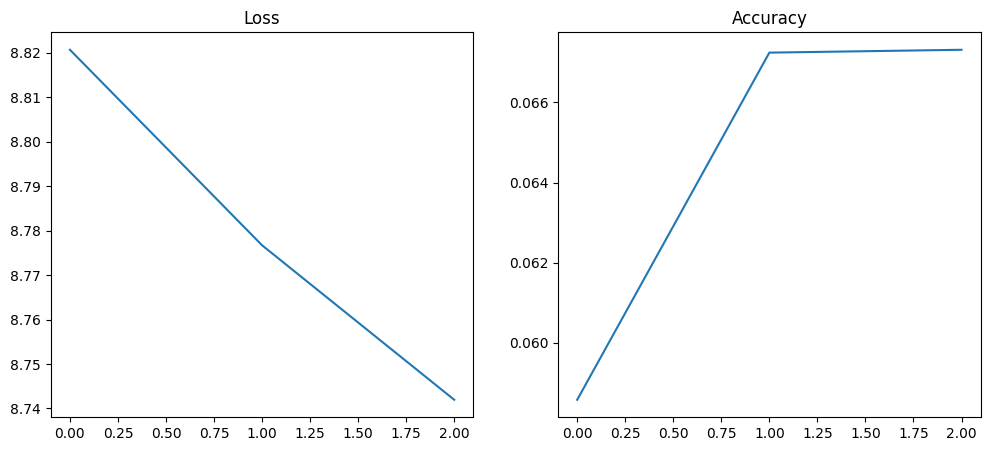

In [314]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(losses)
ax2.plot(accs)
ax1.set_title("Loss")
ax2.set_title("Accuracy")
plt.show()

In [ ]:
torch.save(TaskVec, 'label_extractor_new.pth')

In [165]:


test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
acc = eval_model(model, TaskVec, test_dataloader)
print(f" Evaluation accuracy on test set: {acc:.3f}")
    

 Evaluation accuracy on test set: 0.505


In [143]:
# print(inp_toks)
def generate_from_repr( model, 
                        repr, 
                        taskVector = None, 
                        retr_prompt:str ="_ named",
                        max_tokens = 10,
                        do_sample = False,
                        prepend_bos=True,
                        ):
        """
        Args:
                repr: The representation vectors
                Model: the GPT model to use
                taskVector: the task vector to use. If None, will use default prompt
                max_tokens: num of tokens to generate
                do_sample: if True, sample from logits, else take argmax
                prepend_bos: if True, prepend '<BOS>' token to the input

        """
        inp_toks = model.to_tokens(retr_prompt, prepend_bos=prepend_bos)
        rep_idx = 1 if prepend_bos else 0
        print(rep_idx)
        taskVec_idx = rep_idx + 1
        
        taskVector = taskVector.view(1,-1)
        b_taskVec = taskVector.repeat(repr.shape[0],1)
        # print(b_taskVec.shape)
        # print(repr.shape)
        
        for i in range(max_tokens):

                # print(inputs, targets)
                logits = model.run_with_hooks(
                        inp_toks,
                        return_type = "logits",
                        fwd_hooks=[
                        (replace_hook_name, get_replace_with_rep_hook(repr, rep_idx)), # replace '_' by the subject Representation
                        (replace_hook_name, get_replace_with_rep_hook(b_taskVec, taskVec_idx)) # replace 'called' by TaskVec Representation
                        ])

                final_logits =  logits[0,-1,:] #extract logits for last token 

                if do_sample:
                        new_tok = utils.sample_logits(
                        final_logits,
                        top_k=None,
                        top_p=None,
                        temperature=0,
                        freq_penalty=0,
                        tokens=inp_toks,
                        ).view(1,-1)
                else:
                        #greedy generation
                        new_tok = final_logits.argmax(-1).view(1,-1) 
                
                inp_toks = torch.hstack((inp_toks,new_tok))
                
                if new_tok == model.tokenizer.eos_token_id: break
        print(model.to_string(inp_toks))



In [317]:
ind = np.random.randint(len(test_dataset))
print(test_dataset[ind])
s = test_dataset[ind]["representation"].view(1,-1)

generate_from_repr(model, s, TaskVec)

{'text': 'Harold French was born in 1897. Harold French', 'entity': 'Harold French', 'id': 3405, 'representation': tensor([ 6.3471,  3.0530,  2.9230,  ..., -6.0200,  1.1325,  2.0374]), 'prompt': '_ > Harold French<|endoftext|>'}
1
['<|endoftext|>_ called\n\nThe first thing you should know about the']
